# VPP三阶段优化结果可视化分析

本Notebook用于可视化分析虚拟电厂(VPP)的三阶段优化结果:
1. **日前计划** (max_profit_1)
2. **日内修正** (max_profit_t)
3. **实时分配** (fast_control_implement)

包括:
- 投标策略对比
- 功率平衡分析
- 利润对比
- 资源类型分析(PV/ES/EV)

In [1]:
# 导入必要的库
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib
import platform
from matplotlib import font_manager
import warnings
warnings.filterwarnings('ignore')

# ========== 设置中文字体 ==========
system = platform.system()
print(f"检测到系统: {system}")

# 查找可用的中文字体
def find_chinese_font():
    """查找系统可用的中文字体"""
    chinese_fonts = [
        'Microsoft YaHei',  # 微软雅黑
        'SimHei',           # 黑体
        'SimSun',           # 宋体
        'KaiTi',           # 楷体
        'FangSong',         # 仿宋
        'STHeiti',          # 华文黑体
        'STSong',           # 华文宋体
        'STKaiti',          # 华文楷体
        'PingFang SC',      # 苹方(简体中文)
        'Heiti SC',         # 黑体-简
        'Arial Unicode MS',  # Arial Unicode(支持中文)
        'Noto Sans CJK SC', # Noto无衬线中文简体
        'WenQuanYi Micro Hei',  # 文泉驿微米黑
    ]
    
    available_fonts = [f.name for f in font_manager.fontManager.ttflist]
    
    # 优先查找中文字体
    for font in chinese_fonts:
        if font in available_fonts:
            print(f"找到中文字体: {font}")
            return font
    
    # 如果没有找到中文字体,返回第一个可用字体
    if available_fonts:
        print(f"未找到中文字体,使用: {available_fonts[0]}")
        return available_fonts[0]
    
    return 'sans-serif'

# 设置字体
chinese_font = find_chinese_font()
matplotlib.rcParams['font.sans-serif'] = [chinese_font]
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
matplotlib.rcParams['font.family'] = 'sans-serif'
# 关键修复: 确保保存图片时也使用相同的中文字体
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# ========== 设置样式 ==========
try:
    plt.style.use('seaborn-v0_8-darkgrid')
    print("使用样式: seaborn-v0_8-darkgrid")
except:
    try:
        plt.style.use('seaborn-darkgrid')
        print("使用样式: seaborn-darkgrid")
    except:
        plt.style.use('default')
        print("使用样式: default")

# ========== 重新设置字体（必须在样式设置之后）==========
matplotlib.rcParams['font.sans-serif'] = [chinese_font]
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

# ========== 设置图形参数 ==========
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.format'] = 'png'

print(f"当前字体: {matplotlib.rcParams['font.sans-serif'][0]}")
print("库导入完成!\n")

检测到系统: Windows
找到中文字体: Microsoft YaHei
使用样式: seaborn-v0_8-darkgrid
当前字体: Microsoft YaHei
库导入完成!



## 1. 加载仿真结果

In [2]:
# 设置结果文件路径
# 方法1: 指定具体的结果文件
result_file = 'results/vpp_results_20260301_xxxxxx.csv'  # 请替换为实际文件名

# 方法2: 自动查找最新的结果文件
results_dir = 'results'
if os.path.exists(results_dir):
    csv_files = [f for f in os.listdir(results_dir) if f.startswith('vpp_results_') and f.endswith('.csv') and 'resource' not in f and 'market' not in f]
    if csv_files:
        csv_files.sort(reverse=True)
        result_file = os.path.join(results_dir, csv_files[0])
        print(f"找到最新的结果文件: {result_file}")
    else:
        print(f"在 {results_dir} 目录中未找到结果文件")
else:
    print(f"结果目录 {results_dir} 不存在")

# 加载主结果数据
if os.path.exists(result_file):
    df = pd.read_csv(result_file)
    print(f"数据加载成功!")
    print(f"时间段数: {len(df)}")
    print(f"数据列数: {len(df.columns)}")
    print(f"数据列: {list(df.columns)}\n")
else:
    print(f"文件 {result_file} 不存在!")

找到最新的结果文件: results\vpp_results_20260301_203845.csv
数据加载成功!
时间段数: 24
数据列数: 17
数据列: ['时段', '日前基础功率', '日前调频功率', '修正后基础功率', '修正后调频功率', '日前利润', '实际利润', '日前能量费用', '日前容量收益', '日前里程收益', '实际能量费用', '实际容量收益', '实际里程收益', '实际里程', '实际能量', '实际成本', '修正次数']



## 2. 加载资源汇总数据

In [3]:
# 加载资源汇总数据(按PV/ES/EV分类)
if os.path.exists(results_dir):
    resource_files = [f for f in os.listdir(results_dir) if f.startswith('vpp_resource_summary_') and f.endswith('.csv')]
    if resource_files:
        resource_files.sort(reverse=True)
        resource_file = os.path.join(results_dir, resource_files[0])
        df_resource = pd.read_csv(resource_file)
        print(f"资源汇总数据加载成功: {resource_file}")
        print(f"资源类型: {df_resource['资源类型'].unique().tolist()}")
        print(f"记录数: {len(df_resource)}\n")
    else:
        print("未找到资源汇总数据\n")
else:
    print("结果目录不存在\n")

资源汇总数据加载成功: results\vpp_resource_summary_20260301_203845.csv
资源类型: ['PV', 'ES', 'EV']
记录数: 72



## 3. 加载市场参数数据

In [4]:
# 加载市场参数数据
if os.path.exists(results_dir):
    market_files = [f for f in os.listdir(results_dir) if f.startswith('vpp_market_data_') and f.endswith('.csv')]
    if market_files:
        market_files.sort(reverse=True)
        market_file = os.path.join(results_dir, market_files[0])
        df_market = pd.read_csv(market_file)
        print(f"市场参数数据加载成功: {market_file}")
        print(f"记录数: {len(df_market)}\n")
    else:
        print("未找到市场参数数据\n")
else:
    print("结果目录不存在\n")

市场参数数据加载成功: results\vpp_market_data_20260301_203845.csv
记录数: 24



## 4. 数据概览

In [5]:
# 显示前几行数据
print("主结果数据概览 (前5个时段):")
df.head()

主结果数据概览 (前5个时段):


,时段,日前基础功率,日前调频功率,修正后基础功率,修正后调频功率,日前利润,实际利润,日前能量费用,日前容量收益,日前里程收益,实际能量费用,实际容量收益,实际里程收益,实际里程,实际能量,实际成本,修正次数
0,1,0.000000,1.000000,0.000000,1.000000,130.057298,91.434807,0.000000,49.800240,80.257058,-6.532656,49.800240,48.167223,15.790461,-0.073516,60.617148,0.0
1,2,0.000000,1.000000,0.000000,1.000000,117.495437,104.651256,0.000000,34.764720,82.730717,0.427546,34.764720,69.458991,22.197612,0.006403,52.403063,0.0
2,3,-0.047619,0.952381,-0.047619,0.952381,95.150557,102.864683,-2.939524,39.125714,58.964367,4.465098,39.125714,59.273871,23.999073,0.072333,31.934427,0.0
3,4,0.000000,1.000000,0.000000,1.000000,186.007325,165.460475,0.000000,43.217280,142.790045,-5.804284,43.217280,128.047479,23.616978,-0.099559,46.205946,0.0
4,5,-0.310345,0.689655,-0.354839,0.645161,17.980262,19.357378,-18.034138,36.014400,0.000000,-14.333512,33.690890,0.000000,18.560721,-0.246662,29.472020,0.0


In [6]:
# 显示资源汇总数据
if 'df_resource' in locals():
    print("资源汇总数据概览 (前10条):")
    df_resource.head(10)

资源汇总数据概览 (前10条):


In [7]:
# 统计汇总
print("="*60)
print("统计汇总")
print("="*60)
print(f"日前计划总利润: ${df['日前利润'].sum():.2f}")
print(f"实际总利润: ${df['实际利润'].sum():.2f}")
print(f"利润差异: ${df['实际利润'].sum() - df['日前利润'].sum():.2f} "
      f"({(df['实际利润'].sum() - df['日前利润'].sum()) / df['日前利润'].sum() * 100:+.2f}%)")
print(f"\n日前平均基础功率: {df['日前基础功率'].mean():.4f} MW")
print(f"修正后平均基础功率: {df['修正后基础功率'].mean():.4f} MW")
print(f"日前平均调频功率: {df['日前调频功率'].mean():.4f} MW")
print(f"修正后平均调频功率: {df['修正后调频功率'].mean():.4f} MW")
print(f"平均实际里程: {df['实际里程'].mean():.4f} MW")
print(f"\n修正总次数: {int(df['修正次数'].sum())}")
print(f"最大修正次数(单时段): {int(df['修正次数'].max())}")
print("="*60)

统计汇总
日前计划总利润: $7677.58
实际总利润: $7338.87
利润差异: $-338.71 (-4.41%)

日前平均基础功率: 0.3567 MW
修正后平均基础功率: 0.2996 MW
日前平均调频功率: 1.9074 MW
修正后平均调频功率: 1.8608 MW
平均实际里程: 49.4691 MW

修正总次数: 0
最大修正次数(单时段): 0


## 5. 投标策略对比图

✓ 投标对比图已保存


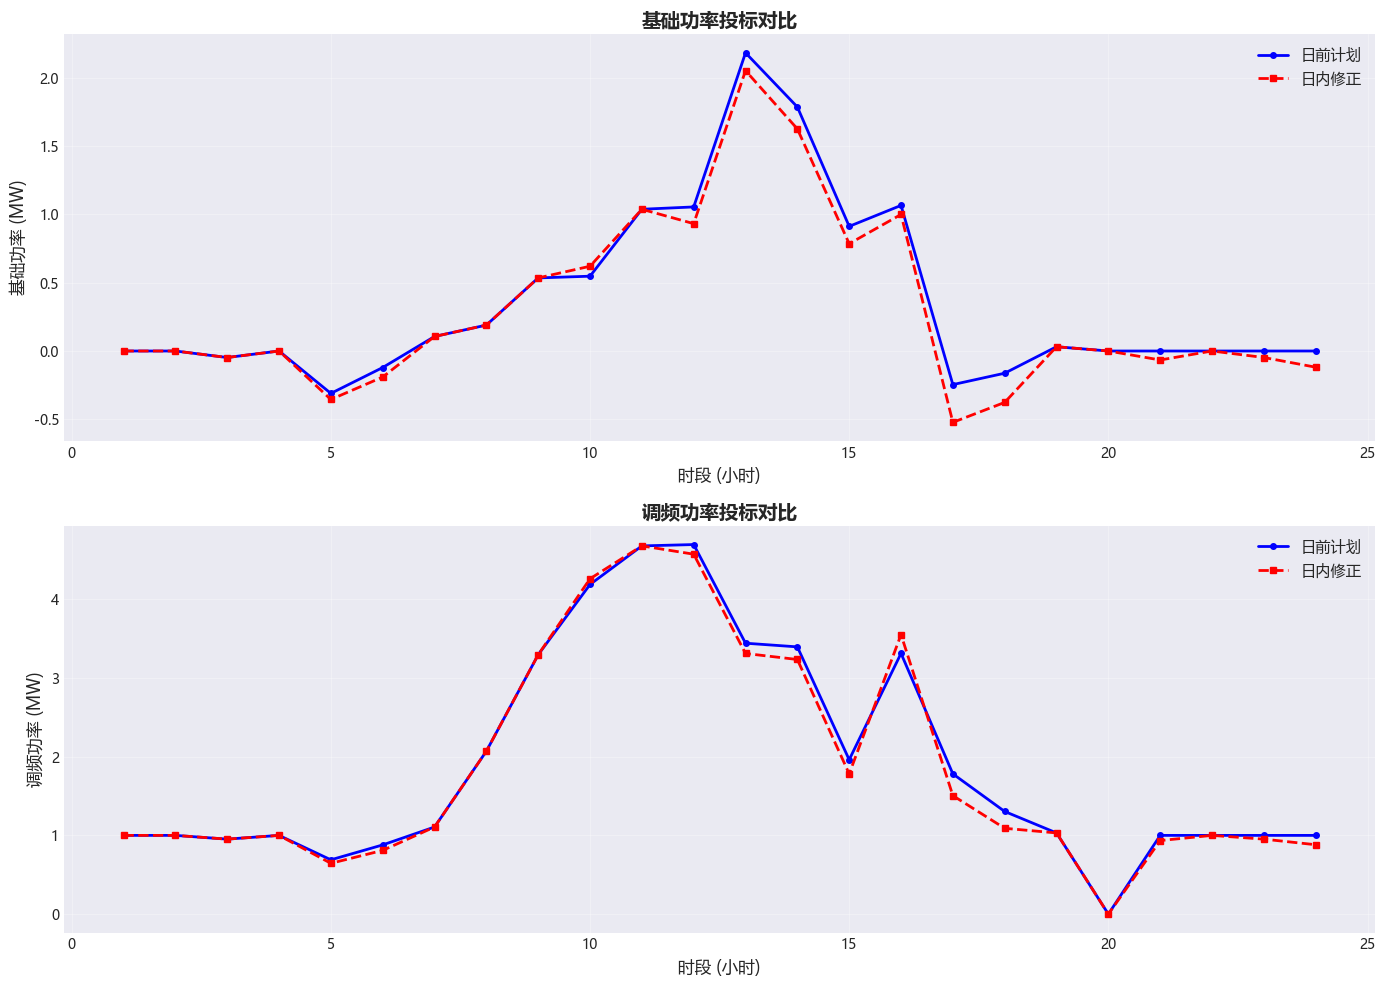

In [8]:
# 基础功率投标对比
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

slots = df['时段']

# 子图1: 基础功率投标
axes[0].plot(slots, df['日前基础功率'], 'b-o', label='日前计划', linewidth=2, markersize=4)
axes[0].plot(slots, df['修正后基础功率'], 'r--s', label='日内修正', linewidth=2, markersize=4)
axes[0].set_xlabel('时段 (小时)', fontsize=12)
axes[0].set_ylabel('基础功率 (MW)', fontsize=12)
axes[0].set_title('基础功率投标对比', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 子图2: 调频功率投标
axes[1].plot(slots, df['日前调频功率'], 'b-o', label='日前计划', linewidth=2, markersize=4)
axes[1].plot(slots, df['修正后调频功率'], 'r--s', label='日内修正', linewidth=2, markersize=4)
axes[1].set_xlabel('时段 (小时)', fontsize=12)
axes[1].set_ylabel('调频功率 (MW)', fontsize=12)
axes[1].set_title('调频功率投标对比', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bidding_comparison.png')
print("✓ 投标对比图已保存")
plt.show()

## 6. 功率平衡分析

✓ 功率平衡图已保存


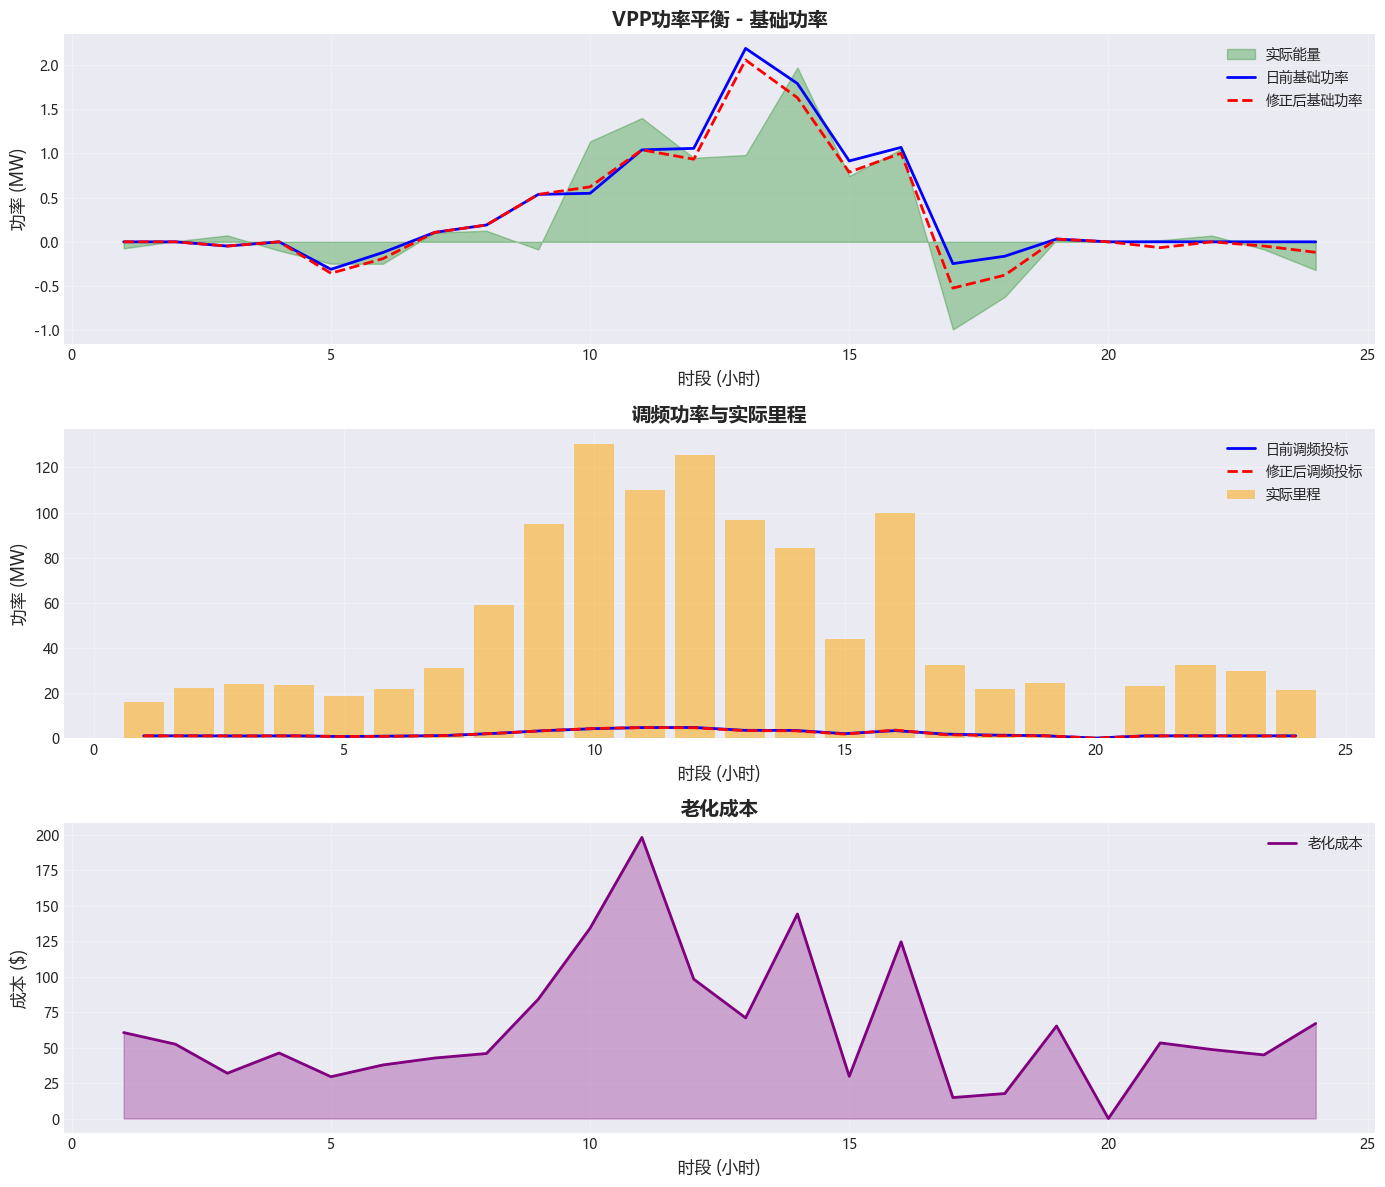

In [9]:
# 功率平衡图
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 子图1: VPP基础功率平衡
axes[0].fill_between(slots, df['实际能量'], alpha=0.3, label='实际能量', color='green')
axes[0].plot(slots, df['日前基础功率'], 'b-', label='日前基础功率', linewidth=2)
axes[0].plot(slots, df['修正后基础功率'], 'r--', label='修正后基础功率', linewidth=2)
axes[0].set_xlabel('时段 (小时)', fontsize=12)
axes[0].set_ylabel('功率 (MW)', fontsize=12)
axes[0].set_title('VPP功率平衡 - 基础功率', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 子图2: 调频响应
axes[1].plot(slots, df['日前调频功率'], 'b-', label='日前调频投标', linewidth=2)
axes[1].plot(slots, df['修正后调频功率'], 'r--', label='修正后调频投标', linewidth=2)
axes[1].bar(slots, df['实际里程'], alpha=0.5, label='实际里程', color='orange')
axes[1].set_xlabel('时段 (小时)', fontsize=12)
axes[1].set_ylabel('功率 (MW)', fontsize=12)
axes[1].set_title('调频功率与实际里程', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# 子图3: 成本
axes[2].plot(slots, df['实际成本'], 'purple', linewidth=2, label='老化成本')
axes[2].fill_between(slots, df['实际成本'], alpha=0.3, color='purple')
axes[2].set_xlabel('时段 (小时)', fontsize=12)
axes[2].set_ylabel('成本 ($)', fontsize=12)
axes[2].set_title('老化成本', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_balance.png')
print("✓ 功率平衡图已保存")
plt.show()

## 7. 利润对比分析

✓ 利润对比图已保存


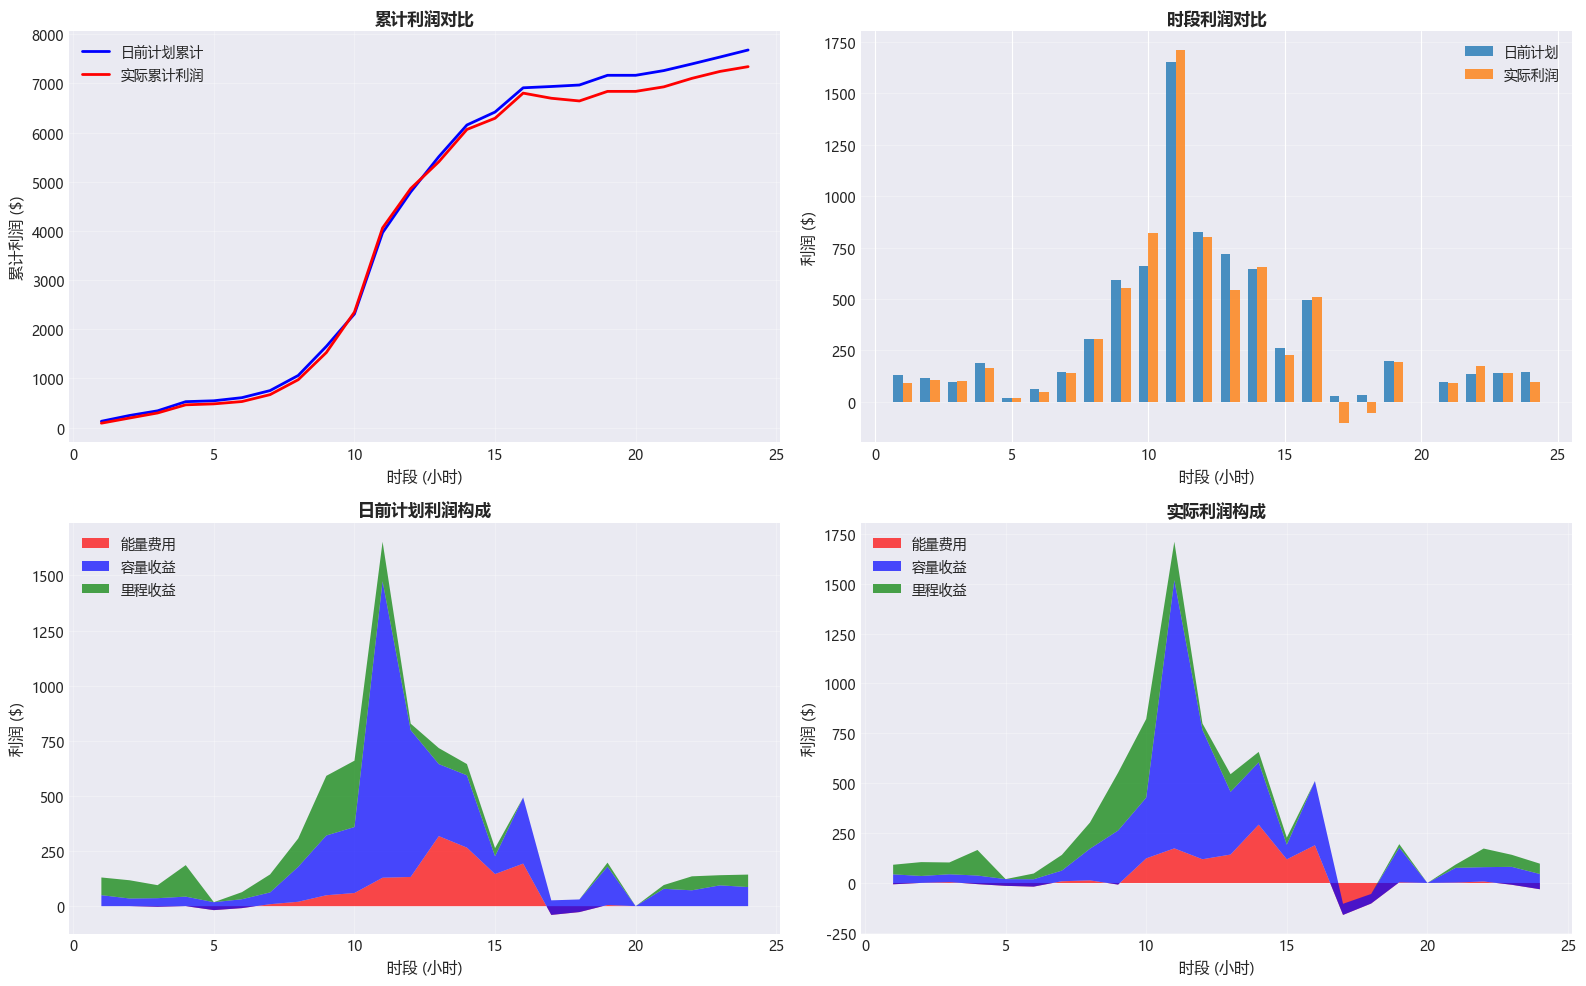

In [10]:
# 利润对比图
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 子图1: 累计利润对比
cum_day = np.cumsum(df['日前利润'])
cum_actual = np.cumsum(df['实际利润'])

axes[0, 0].plot(slots, cum_day, 'b-', label='日前计划累计', linewidth=2)
axes[0, 0].plot(slots, cum_actual, 'r-', label='实际累计利润', linewidth=2)
axes[0, 0].set_xlabel('时段 (小时)', fontsize=11)
axes[0, 0].set_ylabel('累计利润 ($)', fontsize=11)
axes[0, 0].set_title('累计利润对比', fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3)

# 子图2: 时段利润对比
width = 0.35
axes[0, 1].bar(slots - width/2, df['日前利润'], width, label='日前计划', alpha=0.8)
axes[0, 1].bar(slots + width/2, df['实际利润'], width, label='实际利润', alpha=0.8)
axes[0, 1].set_xlabel('时段 (小时)', fontsize=11)
axes[0, 1].set_ylabel('利润 ($)', fontsize=11)
axes[0, 1].set_title('时段利润对比', fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 子图3: 日前计划利润构成
energy_fee = df['日前能量费用']
reg_cap = df['日前容量收益']
reg_mil = df['日前里程收益']

axes[1, 0].stackplot(slots, energy_fee, reg_cap, reg_mil,
                     labels=['能量费用', '容量收益', '里程收益'],
                     alpha=0.7, colors=['red', 'blue', 'green'])
axes[1, 0].set_xlabel('时段 (小时)', fontsize=11)
axes[1, 0].set_ylabel('利润 ($)', fontsize=11)
axes[1, 0].set_title('日前计划利润构成', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10, loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# 子图4: 实际利润构成
energy_fee_act = df['实际能量费用']
reg_cap_act = df['实际容量收益']
reg_mil_act = df['实际里程收益']

axes[1, 1].stackplot(slots, energy_fee_act, reg_cap_act, reg_mil_act,
                     labels=['能量费用', '容量收益', '里程收益'],
                     alpha=0.7, colors=['red', 'blue', 'green'])
axes[1, 1].set_xlabel('时段 (小时)', fontsize=11)
axes[1, 1].set_ylabel('利润 ($)', fontsize=11)
axes[1, 1].set_title('实际利润构成', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10, loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('profit_comparison.png')
print("✓ 利润对比图已保存")
plt.show()

## 8. 资源类型分析(PV/ES/EV)

✓ 资源类型分析图已保存


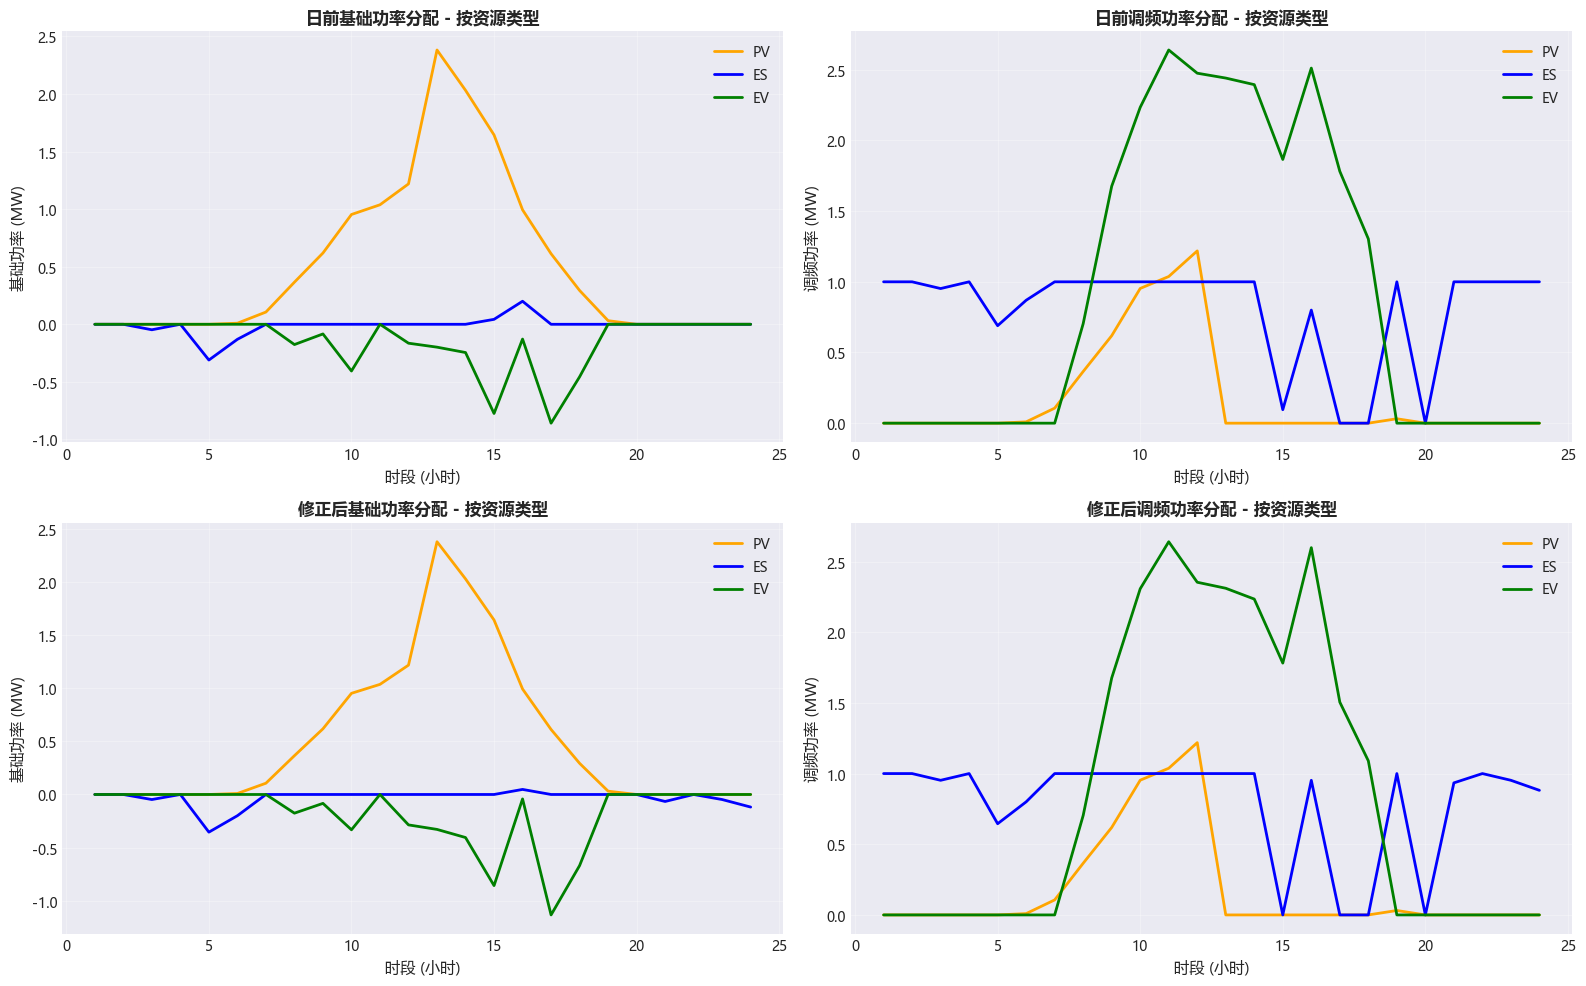

In [11]:
# 按资源类型分析
if 'df_resource' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    colors = {'PV': 'orange', 'ES': 'blue', 'EV': 'green'}
    
    # 子图1: 日前基础功率分配
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        axes[0, 0].plot(df_res['时段'], df_res['日前基础功率'], 
                        label=res_type, color=colors[res_type], linewidth=2)
    axes[0, 0].set_xlabel('时段 (小时)', fontsize=11)
    axes[0, 0].set_ylabel('基础功率 (MW)', fontsize=11)
    axes[0, 0].set_title('日前基础功率分配 - 按资源类型', fontsize=12, fontweight='bold')
    axes[0, 0].legend(fontsize=10)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 子图2: 日前调频功率分配
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        axes[0, 1].plot(df_res['时段'], df_res['日前调频功率'], 
                        label=res_type, color=colors[res_type], linewidth=2)
    axes[0, 1].set_xlabel('时段 (小时)', fontsize=11)
    axes[0, 1].set_ylabel('调频功率 (MW)', fontsize=11)
    axes[0, 1].set_title('日前调频功率分配 - 按资源类型', fontsize=12, fontweight='bold')
    axes[0, 1].legend(fontsize=10)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 子图3: 修正后基础功率分配
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        axes[1, 0].plot(df_res['时段'], df_res['修正后基础功率'], 
                        label=res_type, color=colors[res_type], linewidth=2)
    axes[1, 0].set_xlabel('时段 (小时)', fontsize=11)
    axes[1, 0].set_ylabel('基础功率 (MW)', fontsize=11)
    axes[1, 0].set_title('修正后基础功率分配 - 按资源类型', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=10)
    axes[1, 0].grid(True, alpha=0.3)
    
    # 子图4: 修正后调频功率分配
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        axes[1, 1].plot(df_res['时段'], df_res['修正后调频功率'], 
                        label=res_type, color=colors[res_type], linewidth=2)
    axes[1, 1].set_xlabel('时段 (小时)', fontsize=11)
    axes[1, 1].set_ylabel('调频功率 (MW)', fontsize=11)
    axes[1, 1].set_title('修正后调频功率分配 - 按资源类型', fontsize=12, fontweight='bold')
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('resource_type_analysis.png')
    print("✓ 资源类型分析图已保存")
    plt.show()

## 9. 修正次数分析

## 10. 综合汇总报告

In [13]:
# 生成综合汇总报告
print("="*60)
print("VPP三阶段优化结果汇总报告")
print("="*60)

print(f"\n【日前计划】")
print(f"  总利润: ${df['日前利润'].sum():.2f}")
print(f"  能量费用: ${df['日前能量费用'].sum():.2f}")
print(f"  容量收益: ${df['日前容量收益'].sum():.2f}")
print(f"  里程收益: ${df['日前里程收益'].sum():.2f}")
print(f"  平均基础功率: {df['日前基础功率'].mean():.4f} MW")
print(f"  平均调频功率: {df['日前调频功率'].mean():.4f} MW")

print(f"\n【日内修正】")
print(f"  修正总次数: {int(df['修正次数'].sum())}")
print(f"  修正时段数: {int(np.sum(df['修正次数'] > 0))} 个")
print(f"  修正后利润: ${df['实际利润'].sum():.2f}")
print(f"  修正后基础功率: {df['修正后基础功率'].mean():.4f} MW")
print(f"  修正后调频功率: {df['修正后调频功率'].mean():.4f} MW")

print(f"\n【实时分配】")
print(f"  实际总利润: ${df['实际利润'].sum():.2f}")
print(f"  实际能量费用: ${df['实际能量费用'].sum():.2f}")
print(f"  实际容量收益: ${df['实际容量收益'].sum():.2f}")
print(f"  实际里程收益: ${df['实际里程收益'].sum():.2f}")
print(f"  实际总成本: ${df['实际成本'].sum():.2f}")
print(f"  平均实际里程: {df['实际里程'].mean():.4f} MW")

print(f"\n【对比分析】")
profit_diff = df['实际利润'].sum() - df['日前利润'].sum()
print(f"  利润变化: ${profit_diff:+.2f} ({profit_diff/df['日前利润'].sum()*100:+.2f}%)")
print(f"  基础功率变化: {df['修正后基础功率'].mean() - df['日前基础功率'].mean():+.4f} MW")
print(f"  调频功率变化: {df['修正后调频功率'].mean() - df['日前调频功率'].mean():+.4f} MW")

print(f"\n【性能指标】")
if df['实际里程'].sum() > 0:
    fulfillment_rate = df['实际里程'].sum() / df['修正后调频功率'].sum() * 100
    print(f"  里程满足率: {fulfillment_rate:.2f}%")
print(f"  单位时段平均利润: ${df['实际利润'].mean():.2f}")

# 资源类型统计
if 'df_resource' in locals():
    print(f"\n【资源类型统计】")
    for res_type in ['PV', 'ES', 'EV']:
        df_res = df_resource[df_resource['资源类型'] == res_type]
        print(f"  {res_type}平均基础功率: {df_res['修正后基础功率'].mean():.4f} MW")
        print(f"  {res_type}平均调频功率: {df_res['修正后调频功率'].mean():.4f} MW")

print("\n" + "="*60)
print("报告生成完成!")
print("="*60)

VPP三阶段优化结果汇总报告

【日前计划】
  总利润: $7677.58
  能量费用: $1229.34
  容量收益: $4700.22
  里程收益: $1748.02
  平均基础功率: 0.3567 MW
  平均调频功率: 1.9074 MW

【日内修正】
  修正总次数: 0
  修正时段数: 0 个
  修正后利润: $7338.87
  修正后基础功率: 0.2996 MW
  修正后调频功率: 1.8608 MW

【实时分配】
  实际总利润: $7338.87
  实际能量费用: $842.23
  实际容量收益: $4629.28
  实际里程收益: $1867.36
  实际总成本: $1542.85
  平均实际里程: 49.4691 MW

【对比分析】
  利润变化: $-338.71 (-4.41%)
  基础功率变化: -0.0571 MW
  调频功率变化: -0.0466 MW

【性能指标】
  里程满足率: 2658.47%
  单位时段平均利润: $305.79

【资源类型统计】
  PV平均基础功率: 0.5124 MW
  PV平均调频功率: 0.1809 MW
  ES平均基础功率: -0.0328 MW
  ES平均调频功率: 0.7966 MW
  EV平均基础功率: -0.1800 MW
  EV平均调频功率: 0.8834 MW

报告生成完成!
